In [1]:
import ipywidgets as widgets
from IPython.display import display

**1. Parameter Control**

In [2]:
length = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description="Length [m]:")
mass = widgets.FloatText(value=1.0, description="Mass [kg]:")

display(length, mass)

def update(change):
    print(f"Updated pendulum length: {length.value} m, mass: {mass.value} kg")

length.observe(update, names="value")
mass.observe(update, names="value")


FloatSlider(value=1.0, description='Length [m]:', max=5.0, min=0.1)

FloatText(value=1.0, description='Mass [kg]:')

**2. Dropdown for Subsystem Selection**

In [ ]:
from pyexpat import model
from typing import Dict
from ipywidgets import VBox, HBox, Layout, HTML

# Use HBox/VBox for layout and style for aesthetics

# Styled title
title = HTML("<h4 style='color: #336699; margin-bottom: 10px;'>Subsystem Selection</h4>")

#model_type = widgets.widget_selection.Dropdown()

# Style the dropdown
model_type = widgets.Dropdown(
    options=["Equation-based", "FEM-based", "Data-driven"],
    value="Equation-based",
    description="Model Type:",
    disabled=False)
model_type.layout = Layout(width='250px')
model_type.style = {'description_width': '120px'}

# Add a description label
desc = HTML("<span style='color: #555;'>Choose the type of subsystem model to use:</span>")

# Output area for selection feedback
output = widgets.Output()

def on_change(change):
    with output:
        output.clear_output()
        print(f"Selected subsystem: {change['new']}")

model_type.observe(on_change, names="value")

# Display everything in a vertical box
display(VBox([title, desc, model_type, output], layout=Layout(border='solid 1px #ccc', padding='15px', width='320px', border_radius='8px')))

type(model_type.value)

str

**3. Interactive Simulation Run Button**

In [9]:
# Create a styled Run Simulation button and output area
run_button = widgets.Button(description="Run Simulation")
run_button.layout = Layout(width='200px', height='40px', margin='10px 0px 10px 0px')
run_button.style.button_color = '#28a745'
run_button.icon = 'play'

run_title = HTML("<h4 style='color: #336699; margin-bottom: 8px;'>Simulation Control</h4>")
run_desc = HTML("<span style='color: #555;'>Click to run the simulation with the selected parameters.</span>")

def on_click(b):
    with output:
        output.clear_output()
        print("Simulation started...")
        # Call your simulation function here
        print("Simulation finished.")

run_button.on_click(on_click)

display(VBox([
    run_title,
    run_desc,
    HBox([run_button]),
    output
], layout=Layout(border='solid 1px #ccc', padding='15px', width='320px', border_radius='8px')))

**4. Live Plot with Slider Control**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

time = np.linspace(0, 10, 100)

def plot_response(freq):
    plt.figure()
    plt.plot(time, np.sin(freq * time))
    plt.title(f"System response with freq={freq}")
    plt.show()

widgets.interact(plot_response, freq=(0.1, 5.0, 0.1));


interactive(children=(FloatSlider(value=2.5000000000000004, description='freq', max=5.0, min=0.1), Output()), …

**5. System Configuration Panel**

In [21]:
tab = widgets.Tab()

tab.children = [
    widgets.VBox([widgets.FloatSlider(description="Mass [kg]"), widgets.FloatSlider(description="Length [m]")]),
    widgets.VBox([widgets.Text(description="Solver Type"), widgets.IntSlider(description="Step Size")]),
]

tab.set_title(0, 'Physical Params')
tab.set_title(1, 'Solver Settings')

display(tab)


**6. Visualization of the System Graph**

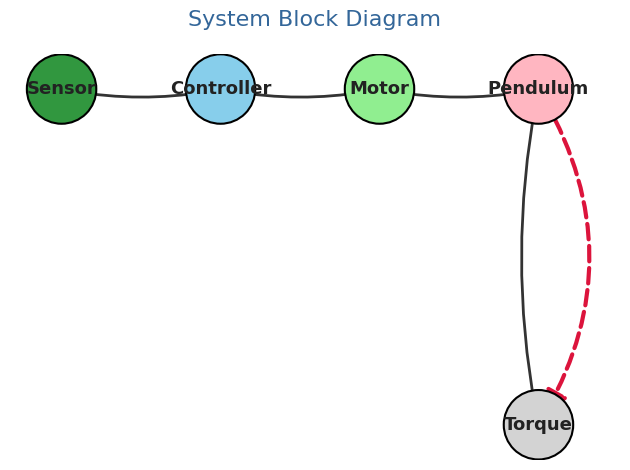

In [24]:
# Add feedback connection from Pendulum to Torque
G.add_edge("Pendulum", "Torque")

# Define node positions for a more structured layout
pos = {
    "Sensor": (0, 1),
    "Controller": (1, 1),
    "Motor": (2, 1),
    "Pendulum": (3, 1),
    "Torque": (3, 0.2)
}

# Define node colors and shapes
node_colors = {
    "Sensor": "#31973F",      # gold
    "Controller": "#87CEEB",  # sky blue
    "Motor": "#90EE90",       # light green
    "Pendulum": "#FFB6C1",    # light pink
    "Torque": "#D3D3D3"       # light gray
}

# Draw nodes with custom colors
nx.draw_networkx_nodes(
    G, pos,
    node_color=[node_colors[n] for n in G.nodes()],
    node_size=2500,
    edgecolors='black',
    linewidths=1.5
)

# Draw edges with arrows and custom style
nx.draw_networkx_edges(
    G, pos,
    arrowstyle='-|>',
    arrowsize=30,
    edge_color='#333',
    width=2,
    connectionstyle='arc3,rad=0.1'
)

# Draw labels with custom font
nx.draw_networkx_labels(
    G, pos,
    font_size=13,
    font_weight='bold',
    font_color='#222'
)

# Highlight feedback edge
feedback_edge = [("Pendulum", "Torque")]
nx.draw_networkx_edges(
    G, pos,
    edgelist=feedback_edge,
    arrowstyle='-|>',
    arrowsize=35,
    edge_color='crimson',
    width=3,
    style='dashed',
    connectionstyle='arc3,rad=-0.3'
)

# Add title and remove axes
plt.gcf().set_facecolor('white')
plt.title("System Block Diagram", fontsize=16, color='#336699', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


In [26]:
import os
from pathlib import Path

# --- 1) Define the system model (nodes, groups, edges) -----------------------
try:
    import networkx as nx
except Exception as e:
    raise RuntimeError("networkx is required for this example") from e

In [27]:
# Logical groups to visually cluster related blocks
GROUPS = {
    "Reference": ["Reference Trajectory", "Reference Angle Sensor"],
    "Sensing": ["State Angle Sensor"],
    "Control": ["PID Controller"],
    "Actuation": ["Drive"],
    "Plant": ["Pendulum"],
}

# Edges with optional signal labels
EDGES = [
    ("Reference Trajectory", "Reference Angle Sensor", "ref θ(t)"),
    ("Reference Angle Sensor", "PID Controller", "U_ref"),
    ("Pendulum", "State Angle Sensor", "θ (state)"),
    ("State Angle Sensor", "PID Controller", "U_meas"),
    ("PID Controller", "Drive", "u (control)"),
    ("Drive", "Pendulum", "τ (torque)"),
    ("Pendulum", "Drive", "ω (feedback)"),
]

# Create a directed graph (for data representation and simple checks)
G = nx.DiGraph()
for group, nodes in GROUPS.items():
    for n in nodes:
        G.add_node(n, group=group)

for u, v, label in EDGES:
    G.add_edge(u, v, label=label)

In [28]:
from graphviz import Digraph

In [30]:
# --- 2) Try rendering with Graphviz (preferred) ------------------------------
svg_path = Path("my_system_block_diagram.svg")
png_fallback_path = Path("my_system_block_diagram.png")

def render_with_graphviz(G, svg_path):
    dot = Digraph(
        "SystemBlockDiagram",
        filename=str(svg_path.with_suffix(".gv")),
        format="svg",
        graph_attr={
            "rankdir": "LR",
            "splines": "ortho",
            "pad": "0.1",
            "nodesep": "0.5",
            "ranksep": "0.75",
            "fontsize": "12",
            "fontname": "Helvetica",
        },
        node_attr={
            "shape": "record",
            "style": "rounded,filled",
            "fillcolor": "white",
            "color": "#3b82f6",  # Tailwind-ish blue
            "penwidth": "1.5",
            "fontname": "Helvetica",
        },
        edge_attr={
            "arrowsize": "0.7",
            "penwidth": "1.2",
            "color": "#111827",  # neutral-900
            "fontname": "Helvetica",
            "fontsize": "10",
        },
    )

    # Subgraphs for "clustered" look
    palette = {
        "Reference": "#dbeafe",   # blue-100
        "Sensing": "#dcfce7",     # green-100
        "Control": "#fee2e2",     # red-100
        "Actuation": "#fef3c7",   # amber-100
        "Plant": "#e5e7eb",       # gray-200
    }

    for group, nodes in GROUPS.items():
        with dot.subgraph(name=f"cluster_{group}") as c:
            c.attr(
                label=group,
                style="rounded",
                color="#9ca3af",       # gray-400 border for clusters
                bgcolor=palette.get(group, "white"),
                fontname="Helvetica",
                fontsize="12",
            )
            for n in nodes:
                # Record-style label for a neat block look
                c.node(n, label=f"{{ {n} }}")

    # Add edges
    for u, v, label in EDGES:
        # Style feedback edges with dashed lines
        style = "dashed" if (u == "Pendulum" and v == "Drive") else "solid"
        dot.edge(u, v, label=label, style=style)

    # Optional: add a legend as its own cluster
    with dot.subgraph(name="cluster_Legend") as legend:
        legend.attr(
            label="Legend",
            style="rounded",
            color="#9ca3af",
            bgcolor="#ffffff",
            fontname="Helvetica",
            fontsize="12",
        )
        legend.node("LegendSignals",
            label="{ Signals | ref θ(t): reference | θ_ref: reference angle | θ_meas: measured angle | u: control | τ: torque | ω: angular velocity }",
            shape="record",
            fillcolor="white",
            color="#6b7280",  # gray-500
        )
        legend.node("LegendStyles",
            label="{ Styles | solid: forward flow | dashed: feedback }",
            shape="record",
            fillcolor="white",
            color="#6b7280",
        )

    # Render to SVG
    svg = dot.render(cleanup=True)
    # Ensure the output path matches expectations
    if svg_path.exists():
        svg_path.unlink()
    os.replace(svg, svg_path)
    return True, f"Rendered SVG to {svg_path}"

ok, msg = render_with_graphviz(G, svg_path)

# --- 3) Fallback: draw with NetworkX + Matplotlib if Graphviz not available ---
fallback_used = False
if not ok:
    fallback_used = True
    import matplotlib.pyplot as plt

    # Compose a manual left-to-right layered layout (coarse) to mimic block diagram
    x_positions = {
        "Reference": 0,
        "Sensing": 2,
        "Control": 3,
        "Actuation": 4,
        "Plant": 5,
    }
    # Stack nodes within each group vertically
    pos = {}
    for group, nodes in GROUPS.items():
        base_x = x_positions[group]
        y0 = 0
        for i, n in enumerate(nodes):
            pos[n] = (base_x, y0 - i * 1.0)

    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(111)
    ax.set_title("System Block Diagram (fallback)")
    ax.axis("off")

    # Draw nodes by group with consistent styling
    for group, nodes in GROUPS.items():
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=nodes,
            node_color="white",
            edgecolors="#3b82f6",
            linewidths=1.5,
            node_size=3000,
        )
        nx.draw_networkx_labels(G, pos, labels={n: n for n in nodes}, font_size=9)

    # Draw edges with labels
    solid_edges = [(u, v) for (u, v, lbl) in EDGES if not (u == "Pendulum" and v == "Drive")]
    dashed_edges = [(u, v) for (u, v, lbl) in EDGES if (u == "Pendulum" and v == "Drive")]

    nx.draw_networkx_edges(G, pos, edgelist=solid_edges, arrows=True, width=1.2, arrowstyle="-|>")
    nx.draw_networkx_edges(G, pos, edgelist=dashed_edges, arrows=True, width=1.2, style="dashed", arrowstyle="-|>")

    edge_labels = {(u, v): lbl for (u, v, lbl) in EDGES}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.5)

    plt.tight_layout()
    fig.savefig(png_fallback_path, dpi=200, bbox_inches="tight")

# Show summary + paths for downloading
summary = {
    "graphviz_rendered": ok,
    "message": msg,
    "fallback_used": fallback_used,
    "svg_path": str(svg_path) if svg_path.exists() else None,
    "png_fallback_path": str(png_fallback_path) if png_fallback_path.exists() else None,
}
summary


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH